## 실습 1. 전처리 데이터 불러오기

해야 할 일

먼저 Chapter 01에서 만든 CSV 파일을 pandas로 불러옵니다.

처음부터 단어를 분리하지 말고 데이터가 정상적으로 연결되는지 먼저 확인합니다.

In [1]:
import pandas as pd  # pandas 라이브러리를 불러옵니다

df_books = pd.read_csv('book_bestseller_clean.csv', encoding='utf-8-sig')  # 같은 폴더의 CSV 파일을 읽어 df_books에 저장합니다

print(df_books.shape)  # 1. 전체 행과 컬럼 개수를 확인합니다

print(df_books.columns)  # 2. 컬럼 이름을 확인합니다

df_books.head()  # 3. 앞의 5행을 확인합니다

(989, 8)
Index(['순위', '판매상품ID', '상품명', '판매가', '저자', '출판사', '발행일', '분야'], dtype='str')


,순위,판매상품ID,상품명,판매가,저자,출판사,발행일,분야
0,1,S000220308313,"세네카, 오늘을 빼앗기고 있는 당신에게",16200,세네카,논픽션,2026-07-01,인문
1,2,S000221143299,홍정기의 장수근육 혁명,17820,홍정기,깸,2026-08-31,건강
2,3,S000000620195,싯다르타,7200,헤르만 헤세,민음사,2002-01-20,소설
3,4,S000221075112,머니 트렌드 2027,24750,정태익 외,북모먼트,2026-09-16,경제/경영
4,5,S000221248222,흔한남매 23,15120,흔한남매,미래엔아이세움,2026-09-16,어린이(초등)


### CSV 파일 불러오기 결과

- `book_bestseller_clean.csv` 파일을 `df_books`로 정상적으로 불러왔습니다.
- 크기: 989행 × 8열로, 전처리 후 저장했던 데이터와 동일합니다.
- 컬럼(순위, 판매상품ID, 상품명, 판매가, 저자, 출판사, 발행일, 분야)과 값들도 그대로 잘 유지되어 있습니다.
- 이제 이 `df_books`를 기준으로 다음 분석을 이어갑니다.

## 실습 2. 분석할 도서 제목 확인하기

단어 분석을 시작하기 전에 상품명 데이터가 어떤 형태인지 직접 확인합니다.

In [11]:
df_books["상품명"].head(20)

0                                세네카, 오늘을 빼앗기고 있는 당신에게
1                                         홍정기의 장수근육 혁명
2                                                 싯다르타
3                                          머니 트렌드 2027
4                                              흔한남매 23
5            2026 해커스 투자자산운용사 실전동형모의고사 10회분+리얼 기출족보 3종
6                                       시대예보: 수고인류의 시간
7                                    리더는 언제 차이를 만들어내는가
8                                               판매의 법칙
9                                              니체의 초월자
10                                        군주론 : 쇼츠 에디션
11                                   한국사 이상현상 연구원(일반판)
12                         2027 해커스경찰 갓대환 형사법 기출총정리 세트
13                                                  테오
14                          쇼펜하우어 인생수업(30만 부 기념 개정증보판)
15                                             마음의 어휘력
16                                                  모순
17    2026 큰별쌤 최태성의 별별한국사 기출 500제 한국사능력검정시험 심화(1,2,3급)
18        

In [10]:
df_books["상품명"].isna().sum()
titles = (
    df_books["상품명"]
    .fillna("")
    .astype(str)
    .str.strip()
)
titles.head()
titles = titles[titles != ""]
print("사용할 제목 개수:", len(titles))

사용할 제목 개수: 989


### 상품명 전처리 결과

- `상품명` 컬럼에는 결측치가 없어(`isna().sum()` 결과 0), 별도 결측치 처리 없이 바로 사용 가능했습니다.
- 혹시 모를 결측치나 공백에 대비해 `fillna("")`, `astype(str)`, `str.strip()`을 적용하고, 빈 문자열을 제외해 `titles`를 만들었습니다.
- 사용할 제목 개수: 989개로, 전체 행 개수와 동일하게 유지되었습니다.

## 실습 3. Dictionary로 단어 빈도 원리 이해하기

빈도 분석의 핵심은 매우 단순합니다.

같은 단어가 등장할 때마다 해당 단어의 숫자를 1씩 증가시키면 됩니다.

예를 들어 다음 단어가 있다고 가정합니다.

In [13]:
sample_words = [
    "데이터",
    "분석",
    "파이썬",
    "데이터",
    "AI",
    "분석",
    "데이터",
]

In [14]:
word_counts = {}
for word in sample_words:
    if word in word_counts:
        word_counts[word] += 1
    else:
        word_counts[word] = 1
print(word_counts)

{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}


get()을 이용하면 더 간단하게 작성할 수 있습니다

In [15]:
word_counts = {}
for word in sample_words:
    word_counts[word] = word_counts.get(word, 0) + 1
print(word_counts)

{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}


### Dictionary로 단어 빈도 원리 이해하기 - 요약

- 빈도 분석의 핵심 원리는 같은 단어가 나올 때마다 숫자를 1씩 늘리는 것입니다.
- `if word in word_counts:` 로 이미 있는 단어인지 확인한 뒤 `+=1` 하거나, 없으면 새로 `=1`로 만드는 방식으로 구현했습니다.
- `word_counts.get(word, 0) + 1`을 쓰면 조건문 없이 한 줄로 같은 결과를 얻을 수 있어 더 간단합니다.
- 두 방식 모두 결과는 동일: 데이터 3, 분석 2, 파이썬 1, AI 1
---

## 실습 4. Counter로 같은 작업 간단하게 처리하기

Python에는 빈도 계산을 도와주는 Counter가 있습니다.

In [16]:
from collections import Counter
sample_counter = Counter(sample_words)
print(sample_counter)

Counter({'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1})


In [17]:
sample_counter.most_common()

[('데이터', 3), ('분석', 2), ('파이썬', 1), ('AI', 1)]

In [ ]:
sample_counter.most_common(3)

### Dictionary와 Counter의 관계

두 방법은 완전히 다른 분석을 하는 것이 아닙니다.

Dictionary

→ 빈도 누적 원리를 직접 이해

Counter

→ 같은 빈도 집계를 더 간단하게 수행

### Counter로 같은 작업 간단하게 처리하기 - 요약

- `Counter(sample_words)`를 사용하면 반복문 없이 한 줄로 단어별 빈도를 계산할 수 있습니다: 데이터 3, 분석 2, 파이썬 1, AI 1
- `most_common()`은 빈도가 높은 순서대로 정렬된 결과를 보여주며, `most_common(3)`처럼 숫자를 넣으면 상위 N개만 뽑을 수 있습니다.
- Dictionary 방식과 Counter는 대립되는 방법이 아니라, Dictionary로 빈도 누적의 원리를 이해한 뒤 Counter로 같은 작업을 더 간단하게 수행하는 관계입니다.

## 실습 5. pandas value_counts()로 빈도 확인하기

pandas에서도 같은 값이 몇 번 등장했는지 쉽게 확인할 수 있습니다.

In [18]:
sample_series = pd.Series(sample_words)

sample_series.value_counts()

데이터    3
분석     2
파이썬    1
AI     1
Name: count, dtype: int64

## 실습 6. 실제 도서 제목을 간단하게 단어로 나누기

이제 실제 상품명 데이터를 사용합니다.

한글 형태소 분석을 사용하기 전에 먼저 정규표현식을 이용해 단순한 토큰화를 해봅니다.

이번 단계의 목적은 완벽한 단어 추출이 아니라 실제 데이터에서도 빈도 집계 흐름이 어떻게 연결되는지 확인하는 것입니다.

In [19]:
import re

def simple_tokenize(text):

    return re.findall(r"[가-힣A-Za-z0-9]+", str(text).lower())

In [20]:
sample_title = "AI 시대의 데이터 분석, Python으로 시작하기!"

simple_tokenize(sample_title)

['ai', '시대의', '데이터', '분석', 'python으로', '시작하기']

## 실습 7. 모든 제목에서 단어 추출하기

먼저 단순 토큰화 방식으로 모든 제목의 단어를 하나의 리스트에 모아봅니다.

In [21]:
simple_words = []
for title in titles:
    words = simple_tokenize(title)
    simple_words.extend(words)
print("전체 단어 수:", len(simple_words))
print(simple_words[:50])

전체 단어 수: 4247
['세네카', '오늘을', '빼앗기고', '있는', '당신에게', '홍정기의', '장수근육', '혁명', '싯다르타', '머니', '트렌드', '2027', '흔한남매', '23', '2026', '해커스', '투자자산운용사', '실전동형모의고사', '10회분', '리얼', '기출족보', '3종', '시대예보', '수고인류의', '시간', '리더는', '언제', '차이를', '만들어내는가', '판매의', '법칙', '니체의', '초월자', '군주론', '쇼츠', '에디션', '한국사', '이상현상', '연구원', '일반판', '2027', '해커스경찰', '갓대환', '형사법', '기출총정리', '세트', '테오', '쇼펜하우어', '인생수업', '30만']


In [22]:
example = []
example.append(["데이터", "분석"])
print(example)

[['데이터', '분석']]


In [23]:
example = []
example.extend(["데이터", "분석"])
print(example)

['데이터', '분석']


## 실습 8. 실제 데이터에서 Counter로 빈도 확인하기

In [24]:
simple_counter = Counter(simple_words)

simple_counter.most_common(30)

[('2027', 93),
 ('2026', 57),
 ('1', 39),
 ('해커스', 38),
 ('기본서', 30),
 ('2', 28),
 ('세트', 25),
 ('에디션', 22),
 ('기출문제집', 21),
 ('토익', 20),
 ('the', 18),
 ('기념', 17),
 ('끝내는', 16),
 ('해커스경찰', 15),
 ('한', 15),
 ('모의고사', 15),
 ('ai', 15),
 ('2026년', 15),
 ('해커스공무원', 14),
 ('초판본', 14),
 ('부', 13),
 ('ncs', 13),
 ('공단기', 13),
 ('rc', 12),
 ('lc', 12),
 ('통합', 12),
 ('실전모의고사', 12),
 ('읽는', 12),
 ('공무원', 11),
 ('영어', 11)]

In [25]:
simple_top30 = pd.DataFrame(
    simple_counter.most_common(30),
    columns=["단어", "빈도"]
)
simple_top30

,단어,빈도
0,2027,93
1,2026,57
2,1,39
3,해커스,38
4,기본서,30
5,2,28
6,세트,25
7,에디션,22
8,기출문제집,21
9,토익,20


## 실습 9. pandas로도 실제 단어 빈도 확인하기

앞에서 만든 simple_words 리스트를 pandas Series로 변환합니다.

In [26]:
simple_word_series = pd.Series(simple_words)

simple_word_series.value_counts().head(30)

2027      93
2026      57
1         39
해커스       38
기본서       30
2         28
세트        25
에디션       22
기출문제집     21
토익        20
the       18
기념        17
끝내는       16
해커스경찰     15
한         15
모의고사      15
ai        15
2026년     15
해커스공무원    14
초판본       14
부         13
ncs       13
공단기       13
rc        12
lc        12
통합        12
실전모의고사    12
읽는        12
공무원       11
영어        11
Name: count, dtype: int64

In [27]:
print(simple_counter.most_common(10))

print(simple_word_series.value_counts().head(10))

[('2027', 93), ('2026', 57), ('1', 39), ('해커스', 38), ('기본서', 30), ('2', 28), ('세트', 25), ('에디션', 22), ('기출문제집', 21), ('토익', 20)]
2027     93
2026     57
1        39
해커스      38
기본서      30
2        28
세트       25
에디션      22
기출문제집    21
토익       20
Name: count, dtype: int64


## 실습 10. 왜 형태소 분석이 필요한가? - 요약

- 한국어는 "데이터를", "데이터가", "데이터의"처럼 조사가 붙어서, 공백만으로 단어를 나누면 같은 단어(데이터)가 서로 다른 문자열로 인식됩니다.
- "은/는/이/가/을/를/의" 같은 조사도 단어처럼 분리되어 빈도 분석을 방해할 수 있습니다.
- 이런 문제를 해결하려면 형태소 분석기로 문장을 의미 단위(명사, 조사, 동사 등)로 정확히 나눠야 합니다.
- 이번 실습에서는 도서 제목의 주요 주제를 파악하기 위해, 모든 품사가 아닌 명사만 뽑아서 분석합니다.

## 실습 11. Kiwi 형태소 분석기 설치하기 - 요약

- 한글 형태소 분석 도구 중 Windows에서 설치가 비교적 간단한 `kiwipiepy`를 사용합니다.
- 설치 전 Python 가상환경이 활성화된 상태인지 확인한 뒤, 터미널에서 `python -m pip install kiwipiepy`로 설치합니다.
- `python -m pip show kiwipiepy`로 설치 여부와 버전을 확인할 수 있습니다.
- Notebook에서 바로 설치한 경우, 변경 사항이 반영되도록 커널을 재시작해야 할 수 있습니다.

### kiwipiepy 설치 결과

- `kiwipiepy 0.23.2`와 필요한 의존성(`kiwipiepy_model`, `tqdm`)이 모두 정상적으로 설치되었습니다.
- `pip show`로 확인한 결과 설치 위치가 현재 가상환경(`.venv`) 안으로 정확히 잡혀 있습니다.
- 설치가 완료되었으니, Notebook에서 사용하기 전에 커널을 한 번 재시작해 주세요.

## 실습 12. Kiwi로 한 문장 품사 확인하기 - 요약

- `Kiwi()`로 형태소 분석기를 만들고, `kiwi.tokenize(문장)`으로 문장을 형태소 단위로 나눕니다.
- 각 토큰은 `token.form`(형태), `token.tag`(품사)로 확인할 수 있습니다.
- 이번 실습에서 주로 볼 태그: `NNG`(일반 명사), `NNP`(고유 명사), `SL`(외국어/알파벳) — 데이터, 분석, 파이썬, AI 같은 표현이 여기 해당합니다.
- 주의할 점: 형태소 분석 결과가 항상 정답은 아니며, 신조어·제품명·인물명·영문 약어·붙여 쓴 표현·브랜드명이 포함된 도서 제목에서는 예상과 다르게 분석될 수 있으므로 실제 출력을 꼭 확인해야 합니다.

In [28]:
from kiwipiepy import Kiwi  # 한글 형태소 분석기 Kiwi를 불러옵니다

kiwi = Kiwi()  # Kiwi 분석기를 준비합니다(시간이 몇 초 걸릴 수 있습니다)

sample_title = "AI 시대의 데이터 분석을 위한 파이썬"  # 분석해 볼 예시 문장

tokens = kiwi.tokenize(sample_title)  # 문장을 형태소 단위로 나눕니다
tokens  # 분석 결과를 확인합니다

[Token(form='AI', tag='SL', start=0, len=2),
 Token(form='시대', tag='NNG', start=3, len=2),
 Token(form='의', tag='JKG', start=5, len=1),
 Token(form='데이터', tag='NNG', start=7, len=3),
 Token(form='분석', tag='NNG', start=11, len=2),
 Token(form='을', tag='JKO', start=13, len=1),
 Token(form='위하', tag='VV', start=15, len=2),
 Token(form='ᆫ', tag='ETM', start=16, len=1),
 Token(form='파이썬', tag='NNP', start=18, len=3)]

In [29]:
for token in tokens:  # 나눠진 형태소를 하나씩 꺼내면서
    print(token.form, token.tag)  # 형태(단어)와 품사 태그를 함께 출력합니다

AI SL
시대 NNG
의 JKG
데이터 NNG
분석 NNG
을 JKO
위하 VV
ᆫ ETM
파이썬 NNP


### Kiwi 형태소 분석 실행 결과

- "AI 시대의 데이터 분석을 위한 파이썬" 문장이 9개 형태소로 정확히 분리되었습니다.
- 명사·외국어 표현: AI(SL), 시대(NNG), 데이터(NNG), 분석(NNG), 파이썬(NNP) → 이번 실습에서 분석 대상으로 쓸 단어들입니다.
- 조사·어미 등: 의(JKG), 을(JKO), 위하(VV), ㄴ(ETM) → 명사 중심 분석에서는 제외할 대상입니다.
- 예상대로 명사(NNG, NNP)와 외국어(SL)가 잘 구분되어, 다음 단계에서 이 태그들만 필터링해 사용하면 됩니다.

## 실습 13. 명사 중심으로 단어 추출하기 - 요약

- `TARGET_TAGS = {"NNG", "NNP", "SL"}`로 일반 명사, 고유 명사, 외국어(알파벳)만 분석 대상으로 지정했습니다.
- `extract_words()` 함수는 문장을 Kiwi로 분석한 뒤, 지정한 품사만 골라 공백을 제거하고 영문은 소문자로 통일해 리스트로 반환합니다.
- 영문을 소문자로 통일하는 이유는 "AI"와 "ai"처럼 대소문자만 다른 값을 같은 단어로 집계하기 위해서입니다.
- 테스트 문장 "AI 시대의 데이터 분석을 위한 파이썬"에서 명사·외국어 단어들이 잘 추출되는지 확인합니다.

In [30]:
TARGET_TAGS = {"NNG", "NNP", "SL"}  # 사용할 품사: 일반 명사(NNG), 고유 명사(NNP), 외국어(SL)

def extract_words(text):
    result = []  # 추출한 단어를 담을 빈 리스트
    for token in kiwi.tokenize(str(text)):  # 문장을 형태소 단위로 나눠서 하나씩 확인합니다
        if token.tag in TARGET_TAGS:  # 원하는 품사(명사, 외국어)인 경우에만
            word = token.form.strip().lower()  # 앞뒤 공백 제거 + 영문 소문자로 통일
            result.append(word)  # 결과 리스트에 추가합니다
    return result  # 추출된 단어 리스트를 돌려줍니다

In [31]:
extract_words("AI 시대의 데이터 분석을 위한 파이썬")  # 함수가 잘 동작하는지 테스트합니다

['ai', '시대', '데이터', '분석', '파이썬']

### extract_words 함수 테스트 결과

- "AI 시대의 데이터 분석을 위한 파이썬" 문장에서 `['ai', '시대', '데이터', '분석', '파이썬']`이 추출되었습니다.
- 명사(NNG, NNP)와 외국어(SL)만 정확히 걸러졌고, 조사·어미는 제외되었습니다.
- `AI`가 소문자 `ai`로 통일되어, 이후 대소문자가 달라도 같은 단어로 집계할 수 있음을 확인했습니다.

## 실습 14. 최소 글자수 필터링 적용하기 - 요약

- 한 글자 단어가 지나치게 많으면 빈도 분석 결과 해석이 어려워질 수 있어, `MIN_LENGTH = 2` 기준으로 2글자 이상 단어만 사용하도록 `extract_words()` 함수를 수정했습니다.
- `len(word) >= MIN_LENGTH` 조건을 추가해, 2글자 이상인 명사·외국어 토큰만 결과에 포함시킵니다. (예: `ai`는 2글자라 포함됨)
- 이 기준은 절대적인 규칙이 아니라 이번 분석의 노이즈를 줄이기 위한 선택이며, 한 글자 단어가 중요한 분야라면 기준을 다르게 정해야 합니다.
- 보고서 작성 시에는 "노이즈를 줄이기 위해 2글자 이상의 명사와 영문 토큰을 사용했다"처럼 적용한 기준을 명시하는 것이 좋습니다.

In [45]:
MIN_LENGTH = 2  # 사용할 최소 글자 수 기준 (2글자 미만은 제외)

def extract_words(text):
    result = []  # 추출한 단어를 담을 빈 리스트
    for token in kiwi.tokenize(str(text)):  # 문장을 형태소 단위로 나눠서 하나씩 확인합니다
        if token.tag in TARGET_TAGS:  # 원하는 품사(명사, 외국어)인 경우에만
            word = token.form.strip().lower()  # 앞뒤 공백 제거 + 영문 소문자로 통일
            if len(word) >= MIN_LENGTH:  # 글자 수가 2글자 이상인 경우에만
                result.append(word)  # 결과 리스트에 추가합니다
    return result  # 추출된 단어 리스트를 돌려줍니다

In [46]:
extract_words("동해물과 백두산이 마르고 닳도록 하느님이 보우하사 우리나라 만세 무궁화 삼천리 화려 강산 대한 사람 대한으로 길이 보전하세")  # 함수가 잘 동작하는지 다시 테스트합니다

['동해', '백두산', '하느님', '보우', '나라', '만세', '무궁화', '삼천리', '강산', '사람', '대한', '보전']

### MIN_LENGTH 오류 수정 및 재테스트 결과

- `MIN_LENGTH`에 실수로 문자열이 들어갔던 것을 숫자 `2`로 수정해 오류를 해결했습니다.
- 애국가 가사로 테스트한 결과, `['동해', '백두산', '하느님', '보우', '나라', '만세', '무궁화', '삼천리', '강산', '사람', '대한', '보전']`처럼 2글자 이상 명사가 정상적으로 추출되었습니다.
- 조사·어미가 포함된 표현("마르고", "닳도록" 등)은 예상대로 제외되어 함수가 의도대로 동작함을 확인했습니다.

## 실습 15. 모든 도서 제목에서 명사 추출하기 - 요약

- 반복문으로 `titles`의 모든 제목에 `extract_words()`를 적용하고, 결과를 `filtered_words`에 모두 합쳐서 전체 단어 수와 앞부분을 확인합니다.
- `Counter(filtered_words)`로 단어별 빈도를 계산하고, `most_common(30)`으로 가장 많이 등장한 상위 30개를 뽑아 DataFrame(`noun_top30`)으로 정리합니다.
- 앞서 만든 단순 토큰화 결과(`simple_top30`)와 형태소 분석 결과(`noun_top30`)를 나란히 비교합니다.
- 비교하며 생각해볼 질문: 조사·불필요한 표현이 줄었는지, 의미 있는 주제어가 더 잘 드러나는지, 반대로 중요한 단어가 사라지지는 않았는지 확인합니다.

In [47]:
filtered_words = []  # 모든 제목에서 뽑은 단어를 모을 빈 리스트

for title in titles:  # titles에 담긴 도서 제목을 하나씩 꺼내면서
    words = extract_words(title)  # 해당 제목에서 명사·외국어 단어를 추출하고
    filtered_words.extend(words)  # filtered_words에 이어붙입니다

print("추출된 전체 단어 수:", len(filtered_words))  # 전체 단어가 몇 개인지 확인합니다
print(filtered_words[:50])  # 앞부분 50개를 미리 확인합니다

추출된 전체 단어 수: 3139
['세네카', '오늘', '홍정기', '장수', '근육', '혁명', '싯다르타', '머니', '트렌드', '남매', '해커스', '투자', '자산', '운용사', '실전동형', '모의고사', '리얼', '기출', '족보', '시대', '예보', '인류', '시간', '리더', '차이', '판매', '법칙', '니체', '초월자', '군주론', '쇼츠', '에디션', '한국사', '이상', '현상', '연구원', '일반판', '해커스', '경찰', '갓대환', '형사법', '기출', '정리', '세트', '테오', '쇼펜하우어', '인생', '수업', '기념', '개정']


In [48]:
noun_counter = Counter(filtered_words)  # 단어별 등장 횟수를 계산합니다
noun_counter.most_common(30)  # 가장 많이 등장한 단어 상위 30개를 확인합니다

[('해커스', 79),
 ('기출', 58),
 ('기본', 37),
 ('모의고사', 33),
 ('공무원', 27),
 ('토익', 26),
 ('경찰', 25),
 ('세트', 25),
 ('문제집', 25),
 ('에디션', 24),
 ('기념', 24),
 ('실전', 22),
 ('사랑', 20),
 ('일본어', 19),
 ('the', 18),
 ('시험', 17),
 ('통합', 17),
 ('영어', 17),
 ('ncs', 16),
 ('인생', 15),
 ('국어', 15),
 ('핵심', 15),
 ('ai', 15),
 ('수업', 14),
 ('최신', 14),
 ('능력', 14),
 ('초판본', 14),
 ('시대', 13),
 ('유형', 13),
 ('문제', 13)]

In [49]:
noun_top30 = pd.DataFrame(
    noun_counter.most_common(30),  # 상위 30개 (단어, 빈도) 쌍을 가져와서
    columns=["단어", "빈도"]  # 컬럼 이름을 지정해 DataFrame으로 만듭니다
)
noun_top30

,단어,빈도
0,해커스,79
1,기출,58
2,기본,37
3,모의고사,33
4,공무원,27
5,토익,26
6,경찰,25
7,세트,25
8,문제집,25
9,에디션,24


In [50]:
print("단순 토큰화 상위 단어")
display(simple_top30.head(10))  # 앞서 만든 단순 토큰화 결과 상위 10개

print("형태소 분석 후 상위 단어")
display(noun_top30.head(10))  # 형태소 분석 결과 상위 10개

단순 토큰화 상위 단어


,단어,빈도
0,2027,93
1,2026,57
2,1,39
3,해커스,38
4,기본서,30
5,2,28
6,세트,25
7,에디션,22
8,기출문제집,21
9,토익,20


형태소 분석 후 상위 단어


,단어,빈도
0,해커스,79
1,기출,58
2,기본,37
3,모의고사,33
4,공무원,27
5,토익,26
6,경찰,25
7,세트,25
8,문제집,25
9,에디션,24


### 모든 도서 제목에서 명사 추출하기 - 결과

- 전체 989개 제목에서 총 3,139개의 단어가 추출되었습니다.
- 형태소 분석 후 상위 단어: 해커스(79), 기출(58), 기본(37), 모의고사(33), 공무원(27) 등 — 시험/수험서 관련 단어가 두드러집니다.
- 단순 토큰화와 비교했을 때 가장 큰 차이는, 단순 토큰화 상위권에 있던 `2027`, `2026`, `1`, `2` 같은 숫자·연도가 형태소 분석 후에는 모두 사라지고, 대신 `공무원`, `경찰`, `문제집` 같은 의미 있는 명사가 새로 상위권에 올라왔다는 점입니다.
- `해커스`, `세트`, `에디션`, `토익` 등 브랜드·시리즈명은 두 방식 모두에서 공통적으로 상위권에 남아, 이 데이터에서 실제로 자주 등장하는 표현임을 알 수 있습니다.
- 다만 `기본서`(30) → `기본`(37)처럼 형태소 분석이 단어를 더 잘게 쪼개면서, 원래 붙어 있던 표현의 의미가 다소 흐려지는 경우도 있어 함께 참고할 필요가 있습니다.

## 실습 17. 불용어 목록 만들기 - 요약

- 앞서 확인한 결과에서 `세트`, `개정판`, `에디션`, `리커버`, `한정판`처럼 분석 의미가 크지 않은 단어를 `STOPWORDS` 목록으로 정리했습니다. 처음부터 너무 많이 넣지 않고, 필요할 때 조금씩 추가하는 방식입니다.
- `extract_words()` 함수에 불용어 필터를 추가해, 이제 다음 세 가지 조건을 모두 통과한 단어만 남깁니다: 품사(NNG, NNP, SL) → 길이(2글자 이상) → 불용어 목록에 없는 단어.
- `continue`를 사용해 조건에 안 맞으면 해당 토큰을 건너뛰고 다음 토큰으로 넘어가는 방식으로 각 필터를 구현했습니다.
- 실제 데이터에서 특정 단어가 의미가 있다면 불용어로 넣지 않고 그대로 남겨두는 것이 좋습니다.

In [51]:
TARGET_TAGS = {"NNG", "NNP", "SL"}  # 사용할 품사: 일반 명사, 고유 명사, 외국어
MIN_LENGTH = 2  # 사용할 최소 글자 수 기준

STOPWORDS = {  # 분석에서 제외할 불용어 목록
    "세트",
    "개정판",
    "에디션",
    "리커버",
    "한정판",
}

def extract_words(text):
    result = []
    for token in kiwi.tokenize(str(text)):  # 문장을 형태소 단위로 나눠서 하나씩 확인합니다
        if token.tag not in TARGET_TAGS:  # 원하는 품사가 아니면
            continue  # 건너뛰고 다음 토큰으로 넘어갑니다

        word = token.form.strip().lower()  # 앞뒤 공백 제거 + 영문 소문자로 통일

        if len(word) < MIN_LENGTH:  # 2글자 미만이면
            continue  # 건너뜁니다

        if word in STOPWORDS:  # 불용어 목록에 있으면
            continue  # 건너뜁니다

        result.append(word)  # 세 조건을 모두 통과한 단어만 결과에 추가합니다
    return result

In [52]:
extract_words("한정판 에디션 세트 데이터 분석 파이썬")  # 불용어가 잘 걸러지는지 테스트합니다

['데이터', '분석', '파이썬']

### 불용어 필터 적용 결과

- "한정판 에디션 세트 데이터 분석 파이썬" 문장에서 불용어(한정판, 에디션, 세트)가 모두 제거되고 `['데이터', '분석', '파이썬']`만 남았습니다.
- 품사·길이·불용어 세 가지 필터가 의도대로 정상 동작함을 확인했습니다.
- 이제 이 함수를 전체 도서 제목에 다시 적용해 불용어가 제외된 빈도 결과를 확인할 수 있습니다.

## 실습 18. 최종 단어 목록 만들기 - 요약

- 불용어까지 반영된 `extract_words()`를 전체 제목에 적용해 `final_words`를 만들고, 전체 단어 수와 앞부분을 확인합니다.
- `Counter`로 빈도를 계산하고, 상위 30개를 `top30`이라는 DataFrame(단어, 빈도)으로 정리합니다.
- 완성된 `top30`을 `chapter02_top30_words.csv` 파일로 저장합니다(인덱스 제외, `utf-8-sig` 인코딩).
- `Path(...).exists()`로 파일이 실제로 생성되었는지 확인합니다.

In [53]:
final_words = []  # 최종 단어를 모을 빈 리스트

for title in titles:  # 모든 도서 제목을 하나씩 꺼내면서
    final_words.extend(extract_words(title))  # 품사·길이·불용어 필터를 거친 단어들을 이어붙입니다

print("최종 단어 수:", len(final_words))  # 최종 단어가 몇 개인지 확인합니다
print(final_words[:50])  # 앞부분 50개를 미리 확인합니다

최종 단어 수: 3073
['세네카', '오늘', '홍정기', '장수', '근육', '혁명', '싯다르타', '머니', '트렌드', '남매', '해커스', '투자', '자산', '운용사', '실전동형', '모의고사', '리얼', '기출', '족보', '시대', '예보', '인류', '시간', '리더', '차이', '판매', '법칙', '니체', '초월자', '군주론', '쇼츠', '한국사', '이상', '현상', '연구원', '일반판', '해커스', '경찰', '갓대환', '형사법', '기출', '정리', '테오', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '마음']


In [54]:
final_counter = Counter(final_words)  # 단어별 등장 횟수를 계산합니다
final_counter.most_common(30)  # 가장 많이 등장한 단어 상위 30개를 확인합니다

[('해커스', 79),
 ('기출', 58),
 ('기본', 37),
 ('모의고사', 33),
 ('공무원', 27),
 ('토익', 26),
 ('경찰', 25),
 ('문제집', 25),
 ('기념', 24),
 ('실전', 22),
 ('사랑', 20),
 ('일본어', 19),
 ('the', 18),
 ('시험', 17),
 ('통합', 17),
 ('영어', 17),
 ('ncs', 16),
 ('인생', 15),
 ('국어', 15),
 ('핵심', 15),
 ('ai', 15),
 ('수업', 14),
 ('최신', 14),
 ('능력', 14),
 ('초판본', 14),
 ('시대', 13),
 ('유형', 13),
 ('문제', 13),
 ('공단기', 13),
 ('투자', 12)]

In [55]:
top30 = pd.DataFrame(
    final_counter.most_common(30),  # 상위 30개 (단어, 빈도) 쌍을 가져와서
    columns=["단어", "빈도"]  # 컬럼 이름을 지정해 DataFrame으로 만듭니다
)
top30

,단어,빈도
0,해커스,79
1,기출,58
2,기본,37
3,모의고사,33
4,공무원,27
5,토익,26
6,경찰,25
7,문제집,25
8,기념,24
9,실전,22


In [56]:
top30.to_csv(
    "chapter02_top30_words.csv",  # 저장할 파일 이름
    index=False,  # 인덱스는 저장하지 않습니다
    encoding="utf-8-sig"  # 한글이 깨지지 않는 인코딩을 사용합니다
)

In [57]:
from pathlib import Path  # 파일 존재 여부를 확인하는 도구를 불러옵니다

Path("chapter02_top30_words.csv").exists()  # 파일이 실제로 생성되었는지 True/False로 확인합니다

True

### 최종 단어 목록 만들기 - 결과

- 불용어(세트, 개정판, 에디션, 리커버, 한정판) 제거 후 최종 단어 수는 3,073개로, 필터링 전(3,139개)보다 66개 줄었습니다.
- 상위 단어는 해커스(79), 기출(58), 기본(37), 모의고사(33), 공무원(27) 등으로, 이전 결과와 순위가 거의 동일하게 유지되었습니다. 즉 이번에 제거한 불용어들은 상위 30위 안에 없었던 단어였습니다.
- 상위 30개 단어를 `top30` DataFrame으로 정리하고, `chapter02_top30_words.csv` 파일로 저장했습니다.
- `Path(...).exists()` 결과 `True`로 파일이 정상적으로 생성된 것을 확인했습니다.

## 실습 19. 상위 단어를 막대그래프로 먼저 확인하기 - 요약

- Word Cloud를 만들기 전에, 정확한 빈도 비교를 위해 상위 30개 단어를 가로 막대그래프(`barh`)로 먼저 확인합니다.
- `top30`을 빈도 오름차순으로 정렬한 뒤 그려야, 그래프에서 가장 빈도 높은 단어가 위쪽에 표시됩니다.
- Windows에서 한글이 깨질 경우 `plt.rcParams["font.family"] = "Malgun Gothic"`으로 한글 폰트를 지정하고, `axes.unicode_minus = False`로 마이너스 기호 깨짐도 방지합니다.
- 확인할 점: 한글이 정상적으로 표시되는지, 가장 빈도 높은 단어가 표(top30)와 일치하는지, 막대 길이가 빈도 숫자와 자연스럽게 비례하는지 점검합니다.

In [60]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"  # 한글이 깨지지 않도록 폰트를 지정합니다 (Windows 기준)
plt.rcParams["axes.unicode_minus"] = False  # 마이너스(-) 기호가 깨지지 않도록 설정합니다

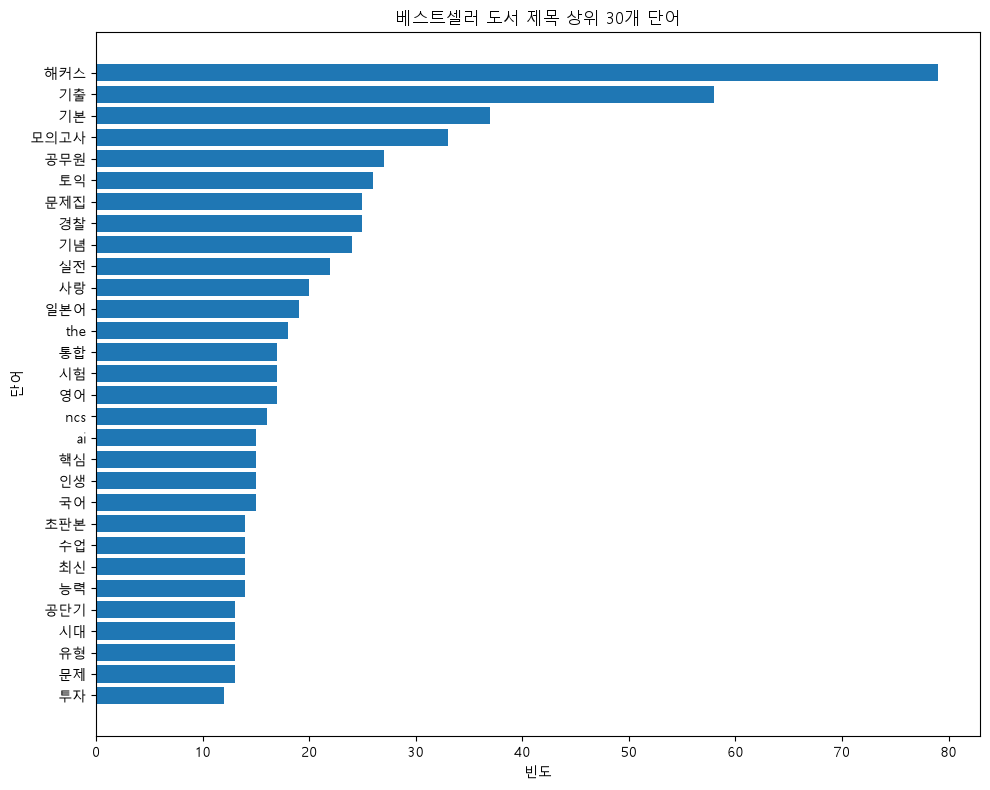

In [61]:
plot_data = top30.sort_values("빈도", ascending=True)  # 그래프에서 빈도가 높은 단어가 위로 오도록 오름차순 정렬합니다

plt.figure(figsize=(10, 8))  # 그래프 크기를 설정합니다
plt.barh(plot_data["단어"], plot_data["빈도"])  # 단어를 y축, 빈도를 x축으로 하는 가로 막대그래프를 그립니다
plt.xlabel("빈도")  # x축 이름
plt.ylabel("단어")  # y축 이름
plt.title("베스트셀러 도서 제목 상위 30개 단어")  # 그래프 제목
plt.tight_layout()  # 요소들이 겹치지 않도록 여백을 자동으로 조정합니다
plt.show()  # 그래프를 화면에 보여줍니다

### 상위 단어 막대그래프 결과

- 한글이 깨지지 않고 정상적으로 표시되었습니다.
- 가장 빈도가 높은 단어는 `해커스`(79)로, 표(top30)와 결과가 일치합니다.
- 막대 길이가 빈도 숫자에 비례해 자연스럽게 그려졌고, 내림차순으로(위에서 아래로 갈수록 값이 작아지게) 잘 정렬되어 한눈에 비교하기 쉽습니다.

## 실습 20. Word Cloud 설치하기 - 요약

- Word Cloud를 만들기 위해 `wordcloud`와 `matplotlib` 라이브러리를 현재 가상환경에 설치합니다: `python -m pip install wordcloud matplotlib`
- `python -m pip show wordcloud`로 설치 여부와 버전을 확인할 수 있습니다.
- Notebook에서 `from wordcloud import WordCloud`가 오류 없이 실행되면 설치가 정상적으로 완료된 것입니다.

In [62]:
from wordcloud import WordCloud  # Word Cloud 라이브러리를 불러옵니다. 오류 없이 실행되면 설치가 잘 된 것입니다

### wordcloud 설치 결과

- `wordcloud 1.9.6`이 정상적으로 설치되었고, `matplotlib`은 이미 설치되어 있어 그대로 사용됩니다.
- `pip show`로 확인한 결과 설치 위치가 현재 가상환경(`.venv`) 안으로 정확히 잡혀 있습니다.
- Notebook에서 `from wordcloud import WordCloud`를 실행하기 전, 커널을 한 번 재시작해 주세요.

## 실습 22. Word Cloud 생성하기 - 요약

- `WordCloud().generate_from_frequencies(final_counter)`로 앞서 계산한 단어 빈도(Counter)를 바로 넣어 Word Cloud를 만듭니다. Counter도 Dictionary처럼 사용할 수 있어 별도 변환이 필요 없습니다.
- 한글 폰트 경로(`font_path`), 이미지 크기, 배경색, 최대 단어 수(100개) 등을 옵션으로 지정합니다.
- `plt.imshow()`로 화면에 Word Cloud를 표시하고, `wordcloud.to_file()`로 `chapter02_wordcloud.png` 파일로 저장합니다.
- `Path(...).exists()`로 이미지 파일이 실제로 생성되었는지 확인합니다.

In [63]:
from pathlib import Path

FONT_PATH = Path("C:/Windows/Fonts/malgun.ttf")  # Windows에 기본 설치된 한글 폰트(맑은 고딕) 경로

In [64]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    font_path=str(FONT_PATH),  # 한글이 깨지지 않도록 폰트 경로를 지정합니다
    width=1200,                # 이미지 가로 크기
    height=700,                # 이미지 세로 크기
    background_color="white",  # 배경색
    max_words=100,              # 표시할 최대 단어 수
    random_state=42,            # 매번 같은 배치로 그려지도록 고정합니다
).generate_from_frequencies(final_counter)  # 단어 빈도(Counter)로 Word Cloud를 생성합니다

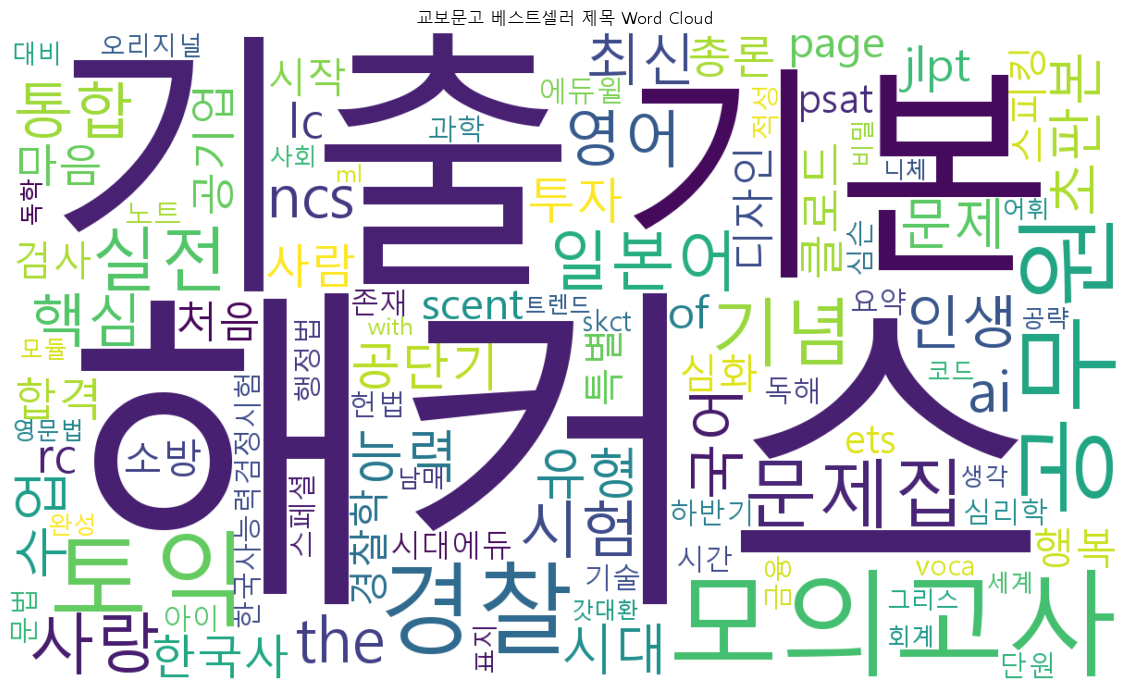

In [65]:
plt.figure(figsize=(12, 7))  # 그래프 크기를 설정합니다
plt.imshow(wordcloud, interpolation="bilinear")  # Word Cloud 이미지를 부드럽게 표시합니다
plt.axis("off")  # 좌표축(눈금)을 숨깁니다
plt.title("교보문고 베스트셀러 제목 Word Cloud")  # 제목을 붙입니다
plt.tight_layout()
plt.show()  # 화면에 출력합니다

In [66]:
wordcloud.to_file("chapter02_wordcloud.png")  # 이미지 파일로 저장합니다

Path("chapter02_wordcloud.png").exists()  # 파일이 실제로 생성되었는지 확인합니다

True

### Word Cloud 생성 결과

- 한글 폰트가 정상적으로 표시되어, `기출`, `해커스`, `경찰`, `모의고사` 등 상위 빈도 단어일수록 크게 그려졌습니다.
- 막대그래프에서 확인했던 상위 단어들(해커스, 기출, 기본, 모의고사, 경찰 등)이 Word Cloud에서도 눈에 띄게 크게 표시되어 결과가 서로 일치함을 확인했습니다.
- `jlpt`, `psat`, `ncs`, `voca`처럼 영문 시험명·용어도 함께 시각화되어, 이 데이터가 수험서·자격증 관련 도서 비중이 높다는 특징을 한눈에 보여줍니다.